## Introduction

- So goal here is to check if NdLinear layer, which is linear layer based architecture, can work as a good spatial representer or not?
- To do so I will make both architectures very similar, with same dimensions being output after each encoder-decoder layer
- To keep the test controlled the dataset will also remain constant

## Imports

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset, Dataset
import random

## Loading Data

- Here the dataset is of only 3000 STL10 images

In [2]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor()
])

ds = datasets.STL10(root="data/", split="unlabeled", download=True, transform=transform)

Files already downloaded and verified


In [3]:
indices = random.sample(range(len(ds)), 3000)
subset = Subset(ds, indices)

In [4]:
dataset_size = len(subset)
train_size = int(0.8*dataset_size)
test_size = dataset_size - train_size

train_ds, test_ds  = random_split(subset, [train_size, test_size])

In [5]:
class ImageOnlyDataSet(Dataset):
    def __init__(self, original_ds):
        self.ds = original_ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, _ = self.ds[idx]
        return img

train_ds = ImageOnlyDataSet(train_ds)
test_ds = ImageOnlyDataSet(test_ds)

In [6]:
train_loader = DataLoader(
    train_ds,
    batch_size=128, 
    shuffle=True,
    )

test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=True
)

## Basline Model

In [7]:
# Base Encoder using Conv only
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, in_channel, latent_channels):
        super().__init__()
        layers = [] 
        for i in range(len(latent_channels)):
            layers.append(nn.Conv2d(in_channel, latent_channels[i], kernel_size=4, stride=2, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm2d(latent_channels[i]))
            in_channel = latent_channels[i]
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [8]:
class Decoder(nn.Module):
    def __init__(self, out_channel, latent_channels):
        super().__init__()
        layers = []
        latent_channels = latent_channels[::-1]
        for i in range(len(latent_channels)-1):
            layers.append(nn.ConvTranspose2d(latent_channels[i], latent_channels[i+1], kernel_size=4, stride=2, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm2d(latent_channels[i+1]))

        layers.append(nn.ConvTranspose2d(latent_channels[i+1], out_channel, kernel_size=4, stride=2, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm2d(out_channel))        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [9]:
class AutoEncoder(nn.Module):
    def __init__(self, in_channel, latent_channels):
        super().__init__()
        self.encoder = Encoder(in_channel, latent_channels)
        self.decoder = Decoder(in_channel, latent_channels)

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)

        return x_rec

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

In [11]:
conv_ae = AutoEncoder(3, [128, 96, 64, 32])

In [12]:
conv_ae

AutoEncoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Conv2d(128, 96, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): ReLU()
      (5): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): Conv2d(96, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (9): Conv2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): ReLU()
      (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): ConvTranspose2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(64, eps=1e-0

In [13]:
from tqdm import tqdm

def train(model, loader, optimizer, criterion, epochs=20, device="cpu"):
    torch.cuda.reset_max_memory_allocated()

    losses = []
    model.to(device)
    model.train()

    for _ in tqdm(range(epochs)):
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            batch_hat = model(batch)
            
            loss = criterion(batch_hat, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() 

        losses.append(total_loss/len(loader))

    torch.save(model, f"{model.__class__.__name__}.pth")
    return losses


In [14]:
epochs = 20
optimizer = torch.optim.Adam(conv_ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [15]:
base_losses = train(conv_ae, train_loader, optimizer, criterion, epochs, device=device)

c:\Users\manav\miniconda3\envs\ML\lib\site-packages\torch\cuda\memory.py:365: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(
100%|██████████| 20/20 [34:58<00:00, 104.93s/it]


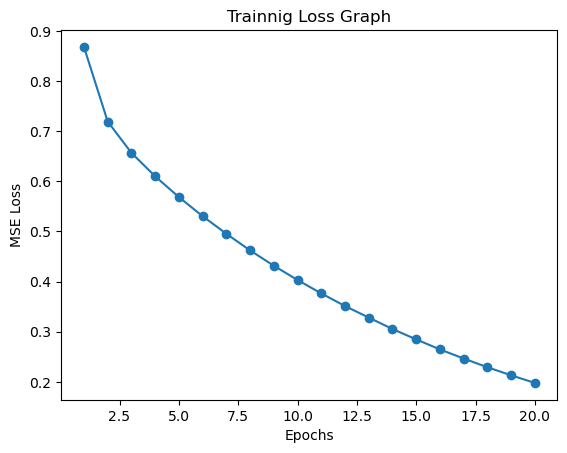

In [16]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(base_losses)+1), base_losses, "-o")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Trainnig Loss Graph")
plt.show()

In [17]:
def eval_loss(model, loader, criterion, device="cpu"):
    torch.cuda.reset_max_memory_allocated()

    model.eval()
    model.to(device)
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        batch_hat = model(batch)
        loss = criterion(batch_hat, batch)
        total_loss += loss.item() 

    return total_loss/len(loader)

In [18]:
print("Reconstruciton Loss : ", eval_loss(conv_ae, test_loader, criterion))

c:\Users\manav\miniconda3\envs\ML\lib\site-packages\torch\cuda\memory.py:365: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(


Reconstruciton Loss :  0.17381637990474702


In [19]:
import time

def model_benchmark(model, device="cpu"):
    torch.cuda.reset_max_memory_allocated()

    model.eval()
    model.to(device)
    # Warm-up
    for _ in range(10):
        model(torch.randn(32, 3, 256, 256, device=device))

    # Measure
    start = time.time()
    for _ in range(100):
        _ = model(torch.randn(32, 3, 256, 256, device=device))
    torch.cuda.synchronize()
    latency_ms = (time.time() - start)/100* 1000
    peak_mem_mb = torch.cuda.max_memory_allocated()/(1024**2)
    print(f"Latency: {latency_ms:.2f} ms — Peak Mem: {peak_mem_mb:.1f} MB")

In [20]:
model_benchmark(conv_ae, device)

Latency: 96.23 ms — Peak Mem: 1333.0 MB


## NdLinear Model

In [21]:
from ndlinear import NdLinear

class NdEncoder(nn.Module):
    def __init__(self, in_dim, latent_channels):
        super().__init__()
        x,y = in_dim[1:]
        layers = [nn.Conv2d(in_dim[0], latent_channels[0], kernel_size=4, stride=2, padding=1)]
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm2d(latent_channels[0]))
        x//=2
        y//=2        
        for i in range(1, len(latent_channels)):
            layers.append(NdLinear((latent_channels[i-1],x,y), (latent_channels[i], x//2, y//2)))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm2d(latent_channels[i]))  
            x//=2
            y//=2         
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [22]:
class NdDecoder(nn.Module):
    def __init__(self, in_dim, latent_channels):
        super().__init__()
        x,y = in_dim[1:]
        l = len(latent_channels)
        x//=2**l
        y//=2**l
        layers = []
        latent_channels = latent_channels[::-1]
        for i in range(len(latent_channels)-1):
            layers.append(NdLinear((latent_channels[i],x,y), (latent_channels[i+1], x*2, y*2)))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm2d(latent_channels[i+1]))
            x*=2
            y*=2

        layers.append(nn.ConvTranspose2d(latent_channels[i+1], in_dim[0], kernel_size=4, stride=2, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm2d(in_dim[0]))        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [23]:
class NdAutoEncoder(nn.Module):
    def __init__(self, in_dim, latent_channels):
        super().__init__()
        self.encoder = NdEncoder(in_dim, latent_channels)
        self.decoder = NdDecoder(in_dim, latent_channels)

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)

        return x_rec

In [24]:
nd_ae = NdAutoEncoder((3, 256, 256), [128, 96, 64, 32])

In [25]:
epochs = 20
optimizer = torch.optim.Adam(nd_ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [26]:
base_losses = train(nd_ae, train_loader, optimizer, criterion, epochs, device=device)

100%|██████████| 20/20 [1:58:27<00:00, 355.35s/it]


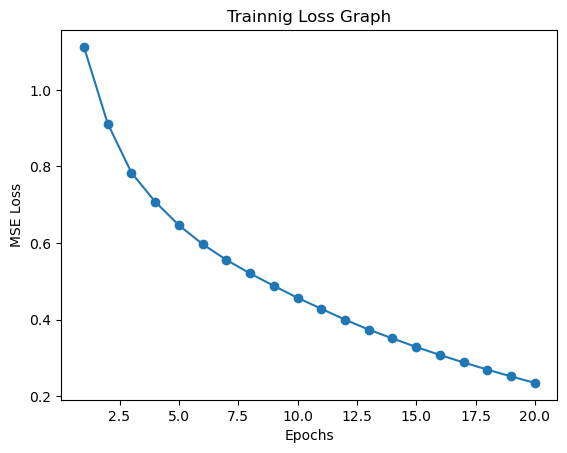

In [27]:
plt.plot(range(1, len(base_losses)+1), base_losses, "-o")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Trainnig Loss Graph")
plt.show()

In [28]:
print("Reconstruciton Loss : ", eval_loss(nd_ae, test_loader, criterion))

Reconstruciton Loss :  0.24158895015716553


In [ ]:
model_benchmark(nd_ae, device)

Latency: 131.26 ms — Peak Mem: 1921.9 MB


## Conclusion:

- So the conv_model has a reconstruction loss of 0.17 and ndlinear_model has a reconstruction loss of 0.24
- Considering, a linear layer is able to capture so much of the image embeddings in just 20 epochs it is performing really well
- Even for inference, latency is not that far off compared to a convolutional model

### What does this mean?

- According to me, i think this linear layer variant is quite adept in capturing spatial representation
- But, is slower than convolution, given it takes the whole dataset instead of chunks